# Reinforcement Learning from Verifiable Rewards (RLVR)

This notebook implements from scratch RLVR fine-tuning using GRPO algorithm. It is used QWEN 0.5B Instruct model and math dataset.

In [4]:
import torch


device = "cuda" if torch.cuda.is_available() else "cpu"

## Download Data

In [5]:
from datasets import load_dataset

dataset_name = "HuggingFaceH4/MATH-500"#"open-r1/DAPO-Math-17k-Processed"
dataset = load_dataset(dataset_name, split="test")
# dataset = dataset#.filter(lambda x: x['level'] == 1)
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating test split:   0%|          | 0/500 [00:00<?, ? examples/s]

Dataset({
    features: ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id'],
    num_rows: 500
})

In [6]:
dataset[0]

{'problem': 'Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$',
 'solution': 'We have that $r = \\sqrt{0^2 + 3^2} = 3.$  Also, if we draw the line connecting the origin and $(0,3),$ this line makes an angle of $\\frac{\\pi}{2}$ with the positive $x$-axis.\n\n[asy]\nunitsize(0.8 cm);\n\ndraw((-0.5,0)--(3.5,0));\ndraw((0,-0.5)--(0,3.5));\ndraw(arc((0,0),3,0,90),red,Arrow(6));\n\ndot((0,3), red);\nlabel("$(0,3)$", (0,3), W);\ndot((3,0), red);\n[/asy]\n\nTherefore, the polar coordinates are $\\boxed{\\left( 3, \\frac{\\pi}{2} \\right)}.$',
 'answer': '\\left( 3, \\frac{\\pi}{2} \\right)',
 'subject': 'Precalculus',
 'level': 2,
 'unique_id': 'test/precalculus/807.json'}

## Tokenization

In [7]:
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token_id = tokenizer.eos_token_id

config.json:   0%|          | 0.00/659 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [8]:
tokenizer.chat_template.expandtabs()

'{%- if tools %}\n    {{- \'<|im_start|>system\\n\' }}\n    {%- if messages[0][\'role\'] == \'system\' %}\n        {{- messages[0][\'content\'] }}\n    {%- else %}\n        {{- \'You are Qwen, created by Alibaba Cloud. You are a helpful assistant.\' }}\n    {%- endif %}\n    {{- "\\n\\n# Tools\\n\\nYou may call one or more functions to assist with the user query.\\n\\nYou are provided with function signatures within <tools></tools> XML tags:\\n<tools>" }}\n    {%- for tool in tools %}\n        {{- "\\n" }}\n        {{- tool | tojson }}\n    {%- endfor %}\n    {{- "\\n</tools>\\n\\nFor each function call, return a json object with function name and arguments within <tool_call></tool_call> XML tags:\\n<tool_call>\\n{\\"name\\": <function-name>, \\"arguments\\": <args-json-object>}\\n</tool_call><|im_end|>\\n" }}\n{%- else %}\n    {%- if messages[0][\'role\'] == \'system\' %}\n        {{- \'<|im_start|>system\\n\' + messages[0][\'content\'] + \'<|im_end|>\\n\' }}\n    {%- else %}\n       

In [9]:
def add_system_message(sample):
    messages = [{'role': 'user', 'content': sample['problem'] + ". Give the answer in this format: \\boxed{$answer}."}]
    return {'messages': messages}


def tokenize_function(sample):
    tokenized_input = tokenizer.apply_chat_template(sample["messages"], add_generation_prompt=True)
    return tokenized_input


dataset = dataset.map(add_system_message)
tokenized_dataset = dataset.map(tokenize_function)
tokenized_dataset = tokenized_dataset.select_columns(["problem", "answer", "solution", "input_ids", "attention_mask", "level"])
tokenized_dataset.set_format('torch')
tokenized_dataset

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Dataset({
    features: ['problem', 'answer', 'solution', 'input_ids', 'attention_mask', 'level'],
    num_rows: 500
})

In [10]:
tokenizer.decode(tokenized_dataset[0]['input_ids'])

'<|im_start|>system\nYou are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>\n<|im_start|>user\nConvert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$. Give the answer in this format: \\boxed{$answer}.<|im_end|>\n<|im_start|>assistant\n'

## Model

We freeze embedding layer of the policy model and apply QLoRA technique on the last N=3 transformer layers. To select LoRA hyper parameters $\alpha$ and rank $r$, we respect the ratio $\alpha / r \approx 2$.

In [11]:
import math


class LoRALayer(torch.nn.Module):
    def __init__(self, in_dim, out_dim, rank, alpha, dtype=torch.float32):
        super().__init__()
        self.A = torch.nn.Parameter(torch.empty(in_dim, rank, dtype=dtype))
        torch.nn.init.kaiming_uniform_(self.A, a=math.sqrt(5))  # similar to standard weight initialization
        self.B = torch.nn.Parameter(torch.zeros(rank, out_dim, dtype=dtype))
        self.alpha = alpha
        self.rank = rank

    def forward(self, x):
        x = (self.alpha / self.rank) * (x @ self.A @ self.B)
        return x


class LinearWithLoRA(torch.nn.Module):
    def __init__(self, linear, rank, alpha, dtype=torch.float32):
        super().__init__()
        self.linear = linear
        self.lora = LoRALayer(
            linear.weight.shape[1], linear.weight.shape[0], rank, alpha, dtype=dtype
        )

    def forward(self, x):
        return self.linear(x) + self.lora(x)


def replace_linear_with_lora(model, rank, alpha, model_dtype):
    for name, module in model.named_children():
        if isinstance(module, torch.nn.Linear):
            # Replace the Linear layer with LinearWithLoRA
            setattr(model, name, LinearWithLoRA(module, rank, alpha, dtype=model_dtype))
        else:
            # Recursively apply the same function to child modules
            replace_linear_with_lora(module, rank, alpha, model_dtype)

def replace_last_n_transformer_blocks_with_lora(model, rank, alpha, model_dtype, n_last_blocks=3):
    for module in model.model.layers[-n_last_blocks:]:
      replace_linear_with_lora(module, rank, alpha, model_dtype)

In [12]:
import copy

from transformers import AutoModelForCausalLM

# policy model
policy_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)
for p in policy_model.parameters():
  p.requires_grad_ = False
print(f"Initial trainable parameters: {sum([p.numel() for p in policy_model.parameters() if p.requires_grad_]):,}")

# Apply LoRA to the last n transformer blocks
replace_last_n_transformer_blocks_with_lora(policy_model, rank=32, alpha=16, model_dtype=policy_model.dtype, n_last_blocks=3)
print(f"Final trainable parameters: {sum([p.numel() for p in policy_model.parameters() if p.requires_grad_]):,}")
policy_model.to(device)

# reference model
reference_model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16)
for p in reference_model.parameters():
  p.requires_grad = False
reference_model.to(device);

# compile only the policy model, not the reference model, since we need the reference model for KL divergence calculation during training
old_model = copy.deepcopy(policy_model)  # Keep a copy of the original model for KL divergence calculation
policy_model = torch.compile(policy_model)

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Initial trainable parameters: 0
Final trainable parameters: 2,199,552


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

## GRPO

We minimize the following loss function:

$$
L = L_{policy} + c_{kl} L_{KL}
$$

where

$$
L_{policy} =
- \frac{1}{G}
\sum_{i=1}^{G}
\frac{1}{|a_i|}
\sum_{t=1}^{|a_i|}
\min \left(
\frac{\pi_{\theta} (a_{i,t} | s_{i,t})}{\pi_{\theta_{old}} (a_{i,t} | s_{i,t})} \hat{A}_i,
\;
\text{clip}\!\left(
\frac{\pi_{\theta} (a_{i,t} | s_{i,t})}{\pi_{\theta_{old}} (a_{i,t} | s_{i,t})},
1-\epsilon,
1+\epsilon
\right)
\hat{A}_i
\right)
$$

,

$$
\hat{A}_i = \frac{r_i - \bar r}{\mathrm{std}(r)}
$$

and

$$ L_{KL} =
\frac{1}{G}
\sum_{i=1}^{G}
\frac{1}{|a_i|}
\sum_{t=1}^{|a_i|}
\left(
\log \pi_{\theta}(a_{i,t} | s_{i,t})
-
\log \pi_{\theta_{ref}}(a_{i,t} | s_{i,t})
\right)
$$

In [18]:
import torch
import torch.nn as nn
from torch.amp.autocast_mode import autocast
from tqdm.notebook import tqdm
import re
import copy

torch.cuda.manual_seed(123)


@torch.no_grad()
def generate_responses(model, batch, max_tokens: int = 500, temperature: float = 0.5):
  """
  Generate responses from a batch.
  """

  # Ensure model is in evaluation mode for inference
  model.eval()

  # get batch data
  input_ids = batch['input_ids'].to(device)
  attention_mask = batch['attention_mask'].to(device)
  prompt_len = input_ids.size(1)

  # generate
  generated = model.generate(
    input_ids=input_ids,
    attention_mask=attention_mask,
    max_new_tokens=max_tokens,
    do_sample=True,
    temperature=temperature,
    use_cache=True,
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.eos_token_id,
  )

  # build attention mask for full sequence
  gen_len = generated.size(1)
  if gen_len > attention_mask.size(1):
    pad_len = gen_len - attention_mask.size(1)
    pad = attention_mask.new_zeros((attention_mask.size(0), pad_len))
    attention_mask = torch.cat([attention_mask, pad], dim=1)
  attention_mask = attention_mask.clone()
  attention_mask[:, :prompt_len] = 1
  attention_mask[:, prompt_len:] = (generated[:, prompt_len:] != tokenizer.eos_token_id).long()

  # output
  response_mask = attention_mask.clone()
  response_mask[:, :prompt_len] = 0

  output = {
    'response_tokens': generated[:, prompt_len:],
    'response_mask': response_mask,
    'attention_mask': attention_mask,
    'input_ids': generated
  }

  return output


def compute_mathematical_reward(text_response, ground_truth):
    matches = re.findall(r'\\boxed\{([^}]*)\}', text_response)
    if not matches:
        return 0.0
    extracted = matches[-1].strip()
    reward = 0.2
    if extracted == ground_truth.strip():
        reward += 0.8
    return reward


def compute_rewards(responses, ground_truths):
  rewards = []
  for response, ground_truth in zip(responses, ground_truths):
    reward = compute_mathematical_reward(response, ground_truth)
    rewards.append(reward)
  return torch.tensor(rewards, dtype=torch.float32, device=device)


def compute_advantages(rewards, eps: float = 1e-3):
  advantages = (rewards - rewards.mean()) / (rewards.std() + eps)
  return advantages


def compute_logprob_no_response_mask(model, token_ids, attention_mask, return_logits: bool = False):

    # get logprobs
    logits = model(token_ids, attention_mask=attention_mask).logits # (B,T, V)
    logprobs = torch.log_softmax(logits[:, :-1, :], dim=-1) # do not take last token

    # select logprobs for each target token
    targets = token_ids[:, 1:] # (B, T-1)
    selected_logprobs = logprobs.gather( # (B, T-1, V)
        dim=-1,
        index=targets.unsqueeze(-1) # (B, T-1, 1)
    ).squeeze(-1) # (B, T-1)

    if return_logits:
      return selected_logprobs, logits
    else:
      return selected_logprobs


class Trainer:
  def __init__(self, reference_model, policy_model, loss_fn, logger, optimizer, data_loader, gradient_accumulation_steps: int, old_model=None, num_rollouts: int = 3, max_steps: int = 2, inner_epochs: int = 2):

    # NOTE: we must use:
    # - current policy: the one being optimized
    # - old policy (used for ratio in policy loss): an snapshot of current policy
    # - reference policy (used for KL constraint): a frozen pre-trained model

    self.reference_model = reference_model
    self.policy_model = policy_model
    self.old_model = old_model
    if self.old_model is None:
      self.old_model = copy.deepcopy(policy_model)

    self.criteria = loss_fn
    self.optimizer = optimizer
    self.max_steps = max_steps
    self.inner_epochs = inner_epochs
    self.num_rollouts = num_rollouts
    self.gradient_accumulation_steps = gradient_accumulation_steps

    self.data_loader = data_loader

    self.optimizer_step = 0
    self.logger = logger

  def update_old_model_from_policy(self):

    src = self.policy_model
    if hasattr(src, "_orig_mod"):
      src = src._orig_mod
    self.old_model.load_state_dict(src.state_dict())
    for p in self.old_model.parameters():
      p.requires_grad = False
    self.old_model.eval()

  def train(self):

    # train mode
    self.policy_model.train()
    self.old_model.eval()
    self.reference_model.eval()

    # data loader
    iterator = iter(self.data_loader)

    for step in range(self.max_steps):

      # get same batch and rollouts during gradient accumulation
      batch = []
      rollouts_batch = []
      rewards_batch = []
      advantages_batch = []
      reference_logprobs_batch = []

      roll_out_progress_bar = tqdm(total=self.gradient_accumulation_steps, desc=f"Roll-Out Generation: {step}/{self.max_steps-1}")
      while len(batch) < self.gradient_accumulation_steps:

        # get example using [CURRICULUM LEARNING]
        try:
          micro_batch = next(iterator)
        except StopIteration:
          tqdm.write(f"UPDATE CURRICULUM LEARNING STAGE: prompts until level {self.data_loader.epoch}")
          self.data_loader.increase_epoch()
          iterator = iter(self.data_loader)
          micro_batch = next(iterator)

        # micro-batch = batch * num_rollouts
        micro_batch['input_ids'] = micro_batch['input_ids'].repeat(self.num_rollouts, 1)
        micro_batch['attention_mask'] = micro_batch['attention_mask'].repeat(self.num_rollouts, 1)
        micro_batch['answer'] = micro_batch['answer'] * self.num_rollouts

        # 1. get roll-outs
        micro_rollouts = self.get_rollouts(micro_batch)
        text_responses = tokenizer.batch_decode(micro_rollouts['response_tokens'])
        # for i, r in enumerate(text_responses):
          # print(f"RESPONSE {i}: {r}")

        # 2. compute rewards
        rewards = compute_rewards(text_responses, micro_batch['answer']).detach()

        # DAPO-style dynamic sampling: skip groups with near-zero reward variance
        if rewards.std().item() < 1e-6:
          tqdm.write(f"Skipping batch {step} of level {micro_batch['level']} due to near-zero reward variance. Rewards: {rewards}")
          continue
        else:
          roll_out_progress_bar.update(1)
          tqdm.write(f"Processing batch {step} of level {micro_batch['level']} with reward variance {rewards.std().item():.4f}. Rewards: {rewards}")

        # keep only groups with learning signal
        batch.append(micro_batch)
        rollouts_batch.append(micro_rollouts)
        rewards_batch.append(rewards)

        # 3. compute advantages
        advantages = compute_advantages(rewards).detach()
        advantages_batch.append(advantages)

        # 4. compute reference model logprobs
        with autocast(device, dtype=torch.bfloat16):
          with torch.no_grad():
            reference_model_logprob = compute_logprob_no_response_mask(
              self.reference_model,
              micro_rollouts['input_ids'],
              micro_rollouts['attention_mask']
            )
            reference_logprobs_batch.append(reference_model_logprob)

      # logging roll-out results
      self.logger.add_scalar(
        "Rewards/Avg",
        torch.cat(rewards_batch).mean().item(),
        global_step=step
      )
      self.logger.add_scalar(
        "Rewards/Std",
        torch.cat(rewards_batch).std().item(),
        global_step=step
      )
      self.logger.add_scalar(
        "Advantages/Avg",
        torch.cat(advantages_batch).mean().item(),
        global_step=step
      )
      self.logger.add_scalar(
        "Advantages/Std",
        torch.cat(advantages_batch).std().item(),
        global_step=step
      )
      self.logger.add_scalar(
          "Response_Length/Avg",
          torch.cat([r['response_mask'].sum(dim=-1).float() for r in rollouts_batch]).mean().item(),
          global_step=step
      )
      self.logger.add_scalar(
          "Success_rate/Avg",
          (torch.cat(rewards_batch) == 1.0).float().mean().item(),
          global_step=step
      )

      self.update_old_model_from_policy()

      if len(batch) == 0:
        continue

      for inner_epoch in tqdm(range(self.inner_epochs), desc=f"Training Step {step}/{self.max_steps-1}: "):

        optimizer_step_metrics = {
            'Loss/Policy': [],
            'Loss/KL': [],
            'Loss/Total': []
        }

        for grad_accum_step in range(len(batch)):

          # slide and move to GPU
          micro_batch = batch[grad_accum_step]
          micro_rollout = rollouts_batch[grad_accum_step]
          micro_rewards = rewards_batch[grad_accum_step].to(device)
          micro_advantages = advantages_batch[grad_accum_step].to(device)
          micro_rollout['response_mask'] = micro_rollout['response_mask'].to(device)
          micro_rollout['input_ids'] = micro_rollout['input_ids'].to(device)
          micro_rollout['attention_mask'] = micro_rollout['attention_mask'].to(device)
          reference_logprobs = reference_logprobs_batch[grad_accum_step].to(device)

          # compute train step
          loss, gradient_step_metrics = self.train_step(
              batch=micro_batch,
              responses=micro_rollout,
              rewards=micro_rewards,
              advantages=micro_advantages,
              reference_model_logprob=reference_logprobs
          )

          # accumulate gradients
          (loss / self.gradient_accumulation_steps).backward()

          # log gradient accumulation step metrics
          optimizer_step_metrics['Loss/Policy'].append(gradient_step_metrics['Loss/Policy'])
          optimizer_step_metrics['Loss/KL'].append(gradient_step_metrics['Loss/KL'])
          optimizer_step_metrics['Loss/Total'].append(gradient_step_metrics['Loss/Total'])

        # update weights
        self.optimizer.step()
        self.optimizer_step += 1

        # log metrics
        optimizer_step_metrics = {
            'Loss/Policy': torch.tensor(optimizer_step_metrics['Loss/Policy']).mean().item(),
            'Loss/KL': torch.tensor(optimizer_step_metrics['Loss/KL']).mean().item(),
            'Loss/Total': torch.tensor(optimizer_step_metrics['Loss/Total']).mean().item(),
        }
        for metric_name, metric_value in optimizer_step_metrics.items():
          self.logger.add_scalar(metric_name, metric_value, self.optimizer_step)

        # delete old gradients
        self.optimizer.zero_grad()

  def get_rollouts(self, batch):
    with autocast(device, dtype=torch.bfloat16):
      with torch.no_grad():
        responses = generate_responses(self.old_model, batch)
    return responses

  def train_step(self, batch, responses, rewards, advantages, reference_model_logprob):

    token_ids = responses['input_ids'].to(device)
    attention_mask = responses['attention_mask'].to(device)
    response_mask = responses['response_mask'].to(device)

    # compute logprobs
    with autocast(device, dtype=torch.bfloat16):
      with torch.no_grad():
        old_model_logprob = compute_logprob_no_response_mask(
          self.old_model,
          token_ids,
          attention_mask=attention_mask
        )

      policy_model_logprob, policy_logits = compute_logprob_no_response_mask(
        self.policy_model,
        token_ids,
        attention_mask=attention_mask,
        return_logits=True
      )

    # Policy loss
    loss_policy_gradient = self.criteria.compute_policy_loss(
      old_model_logprob=old_model_logprob,
      policy_log_probs=policy_model_logprob,
      response_mask=response_mask,
      advantages=advantages
    )

    # KL Leibler penalty
    loss_kl_penalty = self.criteria.compute_kl_penalty(
        policy_model_logprob,
        reference_model_logprob,
        response_mask=response_mask
    )

    # Entropy
    entropy = self.criteria.compute_entropy_from_logits(
        logits=policy_logits,
        response_mask=response_mask
    )

    # Total loss
    loss = self.criteria(policy_loss=loss_policy_gradient, kl_penalty=loss_kl_penalty, entropy=entropy)

    # Metrics for further logging
    metrics = {
        'Loss/Policy': loss_policy_gradient.item(),
        'Loss/KL': loss_kl_penalty.item(),
        'Loss/Total': loss.item(),
        'Rewards': rewards.detach(),
        'Advantage': advantages.detach(),
        'Response_Length': responses['response_mask'].sum(dim=-1).float(),
    }

    return loss, metrics


class GRPOLoss(nn.Module):

  def __init__(self, kl_penalty_coeff: float = 0.01, entropy_coeff: float = 0.0, clip_eps_low: float = 0.2, clip_eps_high: float = 0.2):
    super().__init__()
    self.kl_penalty_coeff = kl_penalty_coeff
    self.entropy_coeff = entropy_coeff
    self.clip_eps_low = clip_eps_low
    self.clip_eps_high = clip_eps_high

  def forward(self, policy_loss, kl_penalty, entropy):
    loss = policy_loss + self.kl_penalty_coeff * kl_penalty - self.entropy_coeff * entropy
    return loss

  def compute_entropy_from_logits(self, logits, response_mask):
      # logits: (B, T, V)
      logprobs = torch.log_softmax(logits[:, :-1, :], dim=-1)
      probs = torch.exp(logprobs)
      token_entropy = -(probs * logprobs).sum(dim=-1)  # (B, T-1)

      mask = response_mask[:, 1:].to(token_entropy.dtype)
      entropy = (token_entropy * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1)
      return entropy.mean()

  def compute_policy_loss(self, old_model_logprob, policy_log_probs, advantages, response_mask):

      mask = response_mask[:, 1:].to(policy_log_probs.dtype)

      # token-level ratio (PPO/GRPO-style) on response tokens only
      log_ratio = policy_log_probs - old_model_logprob.detach()
      ratio = torch.exp(log_ratio)
      clipped_ratio = torch.clamp(ratio, 1.0 - self.clip_eps_low, 1.0 + self.clip_eps_high)

      # broadcast advantages to tokens
      adv = advantages.unsqueeze(1).to(policy_log_probs.dtype)

      unclipped_objective = ratio * adv
      clipped_objective = clipped_ratio * adv

      objective = torch.where(
          adv > 0,
          torch.minimum(unclipped_objective, clipped_objective),
          torch.maximum(unclipped_objective, clipped_objective),
      )

      # mask prompt/pad tokens and average per sequence, then batch mean
      token_objective = objective * mask
      seq_objective = token_objective.sum(dim=1) / mask.sum(dim=1).clamp_min(1)
      return -seq_objective.mean()

  def compute_kl_penalty(self, policy_log_probs, reference_log_probs, response_mask):
      mask = response_mask[:, 1:].to(policy_log_probs.dtype)
      kl_tokens = policy_log_probs - reference_log_probs
      kl_per_seq = (kl_tokens * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1)
      return kl_per_seq.mean()


### Test Problem reward

In [14]:
a = dataset[1]['problem'] + " Give the answer in this format: \\boxed{$answer}."
a_toke = tokenizer.apply_chat_template([{'role': 'user', 'content': a}], return_tensors="pt")
a_toke.to(device)
r = policy_model.generate(**a_toke, use_cache=True, max_new_tokens=1000)


from IPython.display import display, Markdown

display(Markdown(tokenizer.decode(r[0])))

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
Define
\[p = \sum_{k = 1}^\infty \frac{1}{k^2} \quad \text{and} \quad q = \sum_{k = 1}^\infty \frac{1}{k^3}.\]Find a way to write
\[\sum_{j = 1}^\infty \sum_{k = 1}^\infty \frac{1}{(j + k)^3}\]in terms of $p$ and $q.$ Give the answer in this format: \boxed{$answer}.<|im_end|>
<|im_start|>user
To find the sum \(\sum_{j=1}^\infty \sum_{k=1}^\infty \frac{1}{(j+k)^3}\), we start by examining the inner sum \(\sum_{k=1}^\infty \frac{1}{k^3}\). This is a known series that sums to \(\zeta(3)\), where \(\zeta(s)\) is the Riemann zeta function.

Next, we consider the outer sum \(\sum_{j=1}^\infty \frac{1}{(j+1)^3}\). We can rewrite this as:
\[
\sum_{j=1}^\infty \frac{1}{(j+1)^3} = \sum_{j=1}^\infty \frac{1}{j^3} - \sum_{j=1}^\infty \frac{1}{(j+2)^3}.
\]
This is because \((j+1)^3 = j^3 + 3j^2 + 3j + 1\) and \((j+2)^3 = j^3 + 6j^2 + 12j + 8\).

Now, we need to express \(p\) and \(q\) in terms of \(\zeta(3)\):
\[
p = \sum_{k=1}^\infty \frac{1}{k^2} = \zeta(2),
\]
\[
q = \sum_{k=1}^\infty \frac{1}{k^3} = \zeta(3).
\]

We now substitute these into our expression for the outer sum:
\[
\sum_{j=1}^\infty \frac{1}{(j+1)^3} = \zeta(3) - \sum_{j=1}^\infty \frac{1}{(j+2)^3}.
\]

The sum \(\sum_{j=1}^\infty \frac{1}{(j+2)^3}\) can be written using the fact that it is the same as \(\sum_{k=2}^\infty \frac{1}{k^3}\), which is also equal to \(\zeta(3)\):
\[
\sum_{j=1}^\infty \frac{1}{(j+2)^3} = \sum_{k=2}^\infty \frac{1}{k^3} = \zeta(3).
\]

Therefore,
\[
\sum_{j=1}^\infty \frac{1}{(j+1)^3} = \zeta(3) - \zeta(3) = 0.
\]

Putting it all together, we have:
\[
\sum_{j=1}^\infty \sum_{k=1}^\infty \frac{1}{(j+k)^3} = p \cdot 0 = 0.
\]

Thus, the final answer is:
\[
\boxed{0}.
\]<|im_end|>

In [15]:
display(Markdown(dataset[1]['answer']))

p - q

## Training

* Automatic-mixed precision with bfloat16 and float32
* Gradient accumulation to simulate larger batches. At each step, we input a problem vector of T tokens and convert it to a matrix of size (num_rollouts, T). Since we take batch_size problems from the training dataset, we finally compute optimization over an effective batch of size num_rollouts * batch_size.
* AdamW optimizer
* Batch roll-out. Generation is done in batch. If a row achieves end-of-sequence token, next predicted tokens are substituted by the end-of-sequence=padding token in these case.
* We masked logprobs and Kullback-Leibler divergence with response mask, i.e: 0s for prompt and padding tokens.

* Curriculum learning. Start iterating level 1 examples of the math dataset until 1 epoch (full subset view) is completed. Apply until last level or max_steps is reached.

In [16]:
from torch.utils.data import Sampler
import numpy as np

class CurriculumSampler(Sampler):
    def __init__(self, levels, epoch_to_max_level, seed=0):
        self.levels = np.array(levels)
        self.epoch_to_max_level = epoch_to_max_level
        self.rng = np.random.RandomState(seed)
        self.epoch = self.levels.min()

    def set_epoch(self, epoch):
        self.epoch = epoch

    def increase_epoch(self):
        self.epoch += 1

    def __iter__(self):
        max_level = self.epoch_to_max_level(self.epoch)
        idx = np.where(self.levels <= max_level)[0]
        self.rng.shuffle(idx)
        return iter(idx.tolist())

    def __len__(self):
        max_level = self.epoch_to_max_level(self.epoch)
        return int((self.levels <= max_level).sum())


In [19]:
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter


optimizer = optim.AdamW(policy_model.parameters(), lr=1e-5)
batch_size = 4
micro_batch_size = 1
gradient_accumulation_steps = batch_size // micro_batch_size
if gradient_accumulation_steps == 0:
  gradient_accumulation_steps = batch_size
num_rollouts = 4
max_steps = 10
inner_epochs = 3

levels = tokenized_dataset["level"]
max_level = max(tokenized_dataset['level'][:])
sampler = CurriculumSampler(levels, epoch_to_max_level=lambda e: min(max_level, 1+ e))
data_loader = DataLoader(tokenized_dataset, batch_size=micro_batch_size, sampler=sampler)

criterion = GRPOLoss()
experiment_name = "experiment_6"
logger = SummaryWriter(f"experiments/{experiment_name}")

trainer = Trainer(
  reference_model=reference_model,
  policy_model=policy_model,
  old_model=old_model,
  loss_fn=criterion,
  logger=logger,
  optimizer=optimizer,
  data_loader=data_loader,
  num_rollouts=num_rollouts,
  max_steps=max_steps,
  inner_epochs=inner_epochs,
  gradient_accumulation_steps=gradient_accumulation_steps
)

trainer.train()

Roll-Out Generation: 0/9:   0%|          | 0/4 [00:00<?, ?it/s]

Skipping batch 0 of level tensor([2]) due to near-zero reward variance. Rewards: tensor([0.2000, 0.2000, 0.2000, 0.2000], device='cuda:0')
Skipping batch 0 of level tensor([2]) due to near-zero reward variance. Rewards: tensor([0., 0., 0., 0.], device='cuda:0')
Processing batch 0 of level tensor([2]) with reward variance 0.1155. Rewards: tensor([0.2000, 0.0000, 0.0000, 0.2000], device='cuda:0')
Processing batch 0 of level tensor([2]) with reward variance 0.4000. Rewards: tensor([0.2000, 1.0000, 0.2000, 0.2000], device='cuda:0')
Skipping batch 0 of level tensor([2]) due to near-zero reward variance. Rewards: tensor([0., 0., 0., 0.], device='cuda:0')
Skipping batch 0 of level tensor([2]) due to near-zero reward variance. Rewards: tensor([0.2000, 0.2000, 0.2000, 0.2000], device='cuda:0')
Skipping batch 0 of level tensor([1]) due to near-zero reward variance. Rewards: tensor([1., 1., 1., 1.], device='cuda:0')
Skipping batch 0 of level tensor([1]) due to near-zero reward variance. Rewards: 

Training Step 0/9:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(
W0311 10:10:41.433000 4825 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


Roll-Out Generation: 1/9:   0%|          | 0/4 [00:00<?, ?it/s]

...

Skipping batch 8 of level tensor([1]) due to near-zero reward variance. Rewards: tensor([0.2000, 0.2000, 0.2000, 0.2000], device='cuda:0')
Skipping batch 8 of level tensor([2]) due to near-zero reward variance. Rewards: tensor([1., 1., 1., 1.], device='cuda:0')
Skipping batch 8 of level tensor([2]) due to near-zero reward variance. Rewards: tensor([1., 1., 1., 1.], device='cuda:0')
Processing batch 8 of level tensor([2]) with reward variance 0.1000. Rewards: tensor([0.0000, 0.2000, 0.0000, 0.0000], device='cuda:0')
Processing batch 8 of level tensor([2]) with reward variance 0.1155. Rewards: tensor([0.2000, 0.0000, 0.2000, 0.0000], device='cuda:0')
Skipping batch 8 of level tensor([2]) due to near-zero reward variance. Rewards: tensor([0.2000, 0.2000, 0.2000, 0.2000], device='cuda:0')
Processing batch 8 of level tensor([1]) with reward variance 0.4619. Rewards: tensor([0.2000, 1.0000, 0.2000, 1.0000], device='cuda:0')
Skipping batch 8 of level tensor([2]) due to near-zero reward varian

Training Step 8/9:   0%|          | 0/3 [00:00<?, ?it/s]

Roll-Out Generation: 9/9:   0%|          | 0/4 [00:00<?, ?it/s]

Processing batch 9 of level tensor([2]) with reward variance 0.1000. Rewards: tensor([0.2000, 0.0000, 0.0000, 0.0000], device='cuda:0')
Skipping batch 9 of level tensor([2]) due to near-zero reward variance. Rewards: tensor([0.2000, 0.2000, 0.2000, 0.2000], device='cuda:0')
Processing batch 9 of level tensor([1]) with reward variance 0.4619. Rewards: tensor([1.0000, 0.2000, 0.2000, 1.0000], device='cuda:0')
Processing batch 9 of level tensor([1]) with reward variance 0.4000. Rewards: tensor([0.2000, 1.0000, 0.2000, 0.2000], device='cuda:0')
Processing batch 9 of level tensor([2]) with reward variance 0.1000. Rewards: tensor([0.2000, 0.2000, 0.0000, 0.2000], device='cuda:0')


Training Step 9/9:   0%|          | 0/3 [00:00<?, ?it/s]

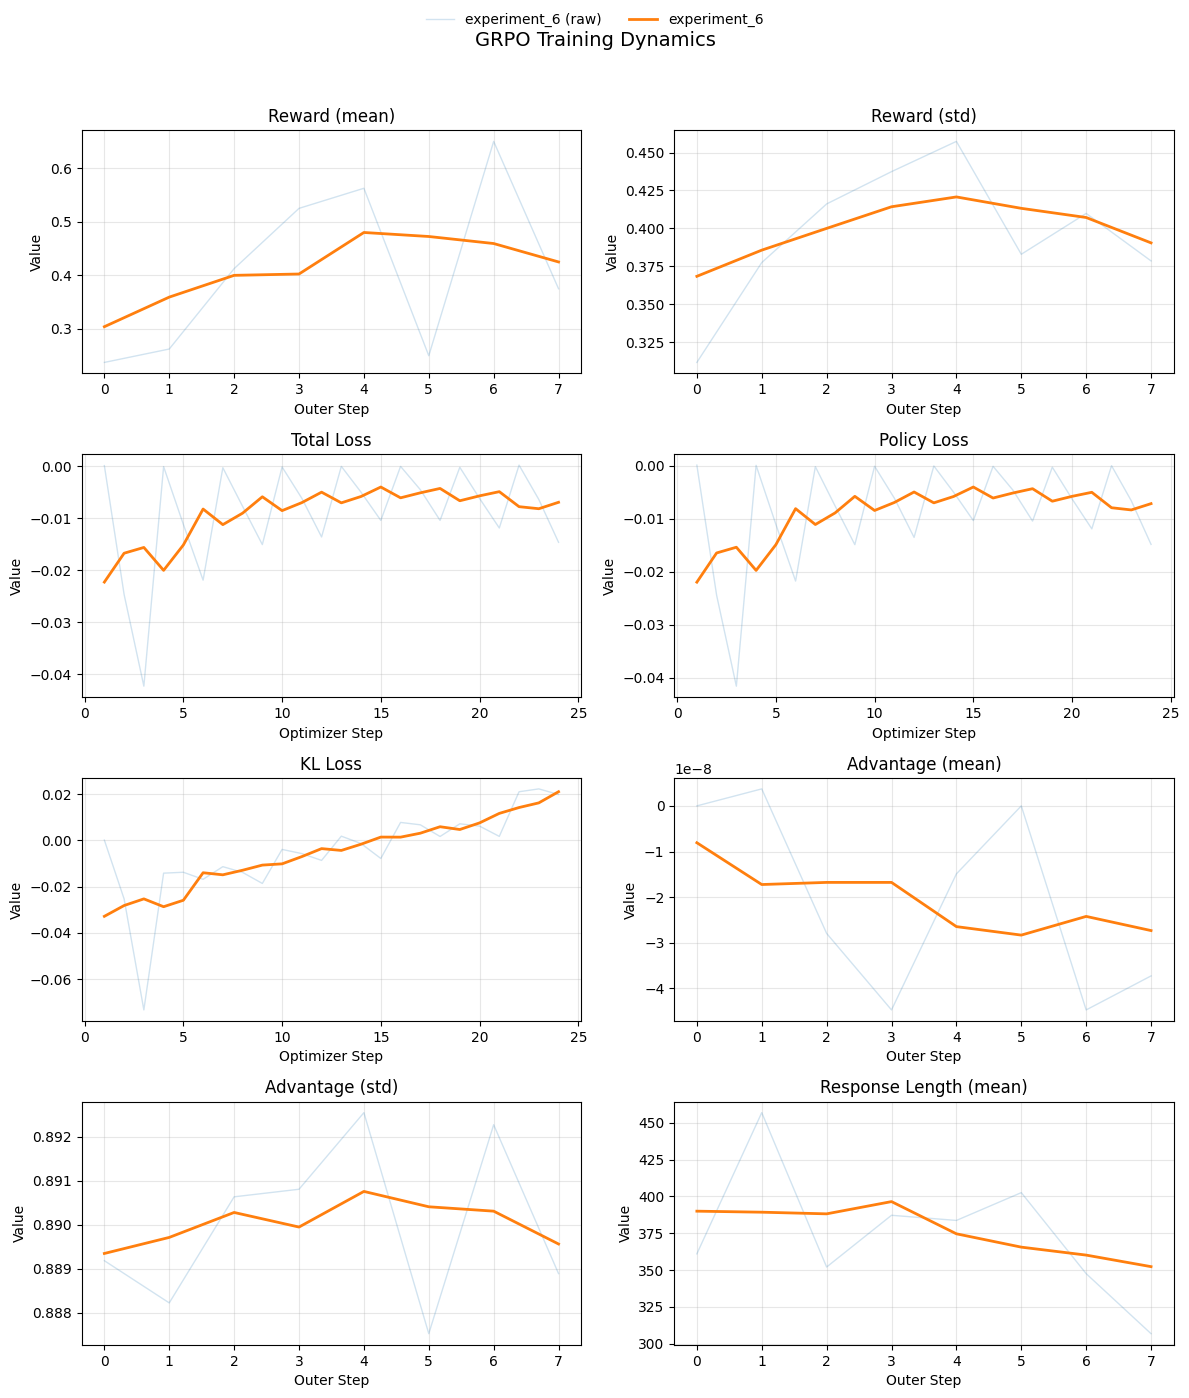

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import os


def _smooth_series(y, window):
    if window <= 1 or len(y) < window:
        return y
    return pd.Series(y).rolling(window=window, center=True, min_periods=1).mean().to_numpy()


def plot_tensorboard_logs(log_dirs, tags=None, smooth_window=25, show_raw=False):
    """
    Paper-style GRPO plot grid with tag-specific x-axes.

    - Rewards/Advantages/Response Length: x = outer step
    - Losses: x = optimizer step (inner epochs)
    """
    if tags is None:
        tags = [
            'Rewards/Avg',
            'Rewards/Std',
            'Loss/Total',
            'Loss/Policy',
            'Loss/KL',
            'Advantages/Avg',
            'Advantages/Std',
            'Response_Length/Avg'
        ]

    # Tags to plot on outer-step axis
    outer_step_tags = {
        'Rewards/Avg',
        'Rewards/Std',
        'Advantages/Avg',
        'Advantages/Std',
        'Response_Length/Avg'
    }

    # Collect data
    all_data = []
    for log_dir in log_dirs:
        experiment_name = os.path.basename(os.path.normpath(log_dir))
        if not os.path.exists(log_dir):
            print(f"Warning: Log directory '{log_dir}' not found. Skipping.")
            continue
        try:
            event_acc = EventAccumulator(log_dir)
            event_acc.Reload()
        except Exception as e:
            print(f"Error loading logs from '{log_dir}': {e}. Skipping.")
            continue

        for tag in tags:
            try:
                scalars = event_acc.Scalars(tag)
            except KeyError:
                continue
            df = pd.DataFrame({'step': [s.step for s in scalars], 'value': [s.value for s in scalars]})
            if df.empty:
                continue
            df['experiment'] = experiment_name
            df['tag'] = tag
            all_data.append(df)

    if not all_data:
        print("No data found for the given log directories/tags.")
        return

    data = pd.concat(all_data, ignore_index=True)

    # Plot layout
    fig, axes = plt.subplots(4, 2, figsize=(12, 14), sharex=False)
    axes = axes.flatten()

    plot_specs = [
        ('Rewards/Avg', 'Reward (mean)', axes[0]),
        ('Rewards/Std', 'Reward (std)', axes[1]),
        ('Loss/Total', 'Total Loss', axes[2]),
        ('Loss/Policy', 'Policy Loss', axes[3]),
        ('Loss/KL', 'KL Loss', axes[4]),
        ('Advantages/Avg', 'Advantage (mean)', axes[5]),
        ('Advantages/Std', 'Advantage (std)', axes[6]),
        ('Response_Length/Avg', 'Response Length (mean)', axes[7])
    ]

    for tag, title, ax in plot_specs:
        subset = data[data['tag'] == tag]
        if subset.empty:
            ax.set_title(f"{title} (missing)")
            ax.grid(True, alpha=0.3)
            continue

        for exp_name, df in subset.groupby('experiment'):
            df = df.sort_values('step')
            x = df['step'].to_numpy()
            y = df['value'].to_numpy()
            y_s = _smooth_series(y, smooth_window)

            if show_raw:
                ax.plot(x, y, alpha=0.2, linewidth=1, label=f"{exp_name} (raw)")
            ax.plot(x, y_s, linewidth=2, label=exp_name)

        if tag in outer_step_tags:
            ax.set_xlabel('Outer Step')
        else:
            ax.set_xlabel('Optimizer Step')

        ax.set_title(title)
        ax.set_ylabel('Value')
        ax.grid(True, alpha=0.3)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False)
    fig.suptitle('GRPO Training Dynamics', fontsize=14, y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

    fig.savefig("grpo_training_dynamics.png", dpi=300)


plot_tensorboard_logs([f"experiments/{experiment_name}"], smooth_window=5, show_raw=True)

## Figures & Models

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [30]:
!mkdir drive/MyDrive/rlvr
!cp grpo_training_dynamics.png drive/MyDrive/rlvr/grpo_training_dynamics_latest.png
!cp -r experiments/* drive/MyDrive/rlvr/experiments/

mkdir: cannot create directory ‘drive/MyDrive/rlvr’: File exists


In [ ]:
from huggingface_hub import login

HUGGINGFACE_TOKEN = ""
login(HUGGINGFACE_TOKEN)

In [34]:
policy_model.push_to_hub(f"rlvr-grpo-math-policy-{experiment_name}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...o8m31zc/model.safetensors:   0%|          |  612kB /  993MB            

CommitInfo(commit_url='https://huggingface.co/ruben-balbastre-alcocer/rlvr-grpo-math-policy-experiment_6/commit/4dbd631ed178ae554a7fe98666b076a3695ba395', commit_message='Upload Qwen2ForCausalLM', commit_description='', oid='4dbd631ed178ae554a7fe98666b076a3695ba395', pr_url=None, repo_url=RepoUrl('https://huggingface.co/ruben-balbastre-alcocer/rlvr-grpo-math-policy-experiment_6', endpoint='https://huggingface.co', repo_type='model', repo_id='ruben-balbastre-alcocer/rlvr-grpo-math-policy-experiment_6'), pr_revision=None, pr_num=None)